# 15 Robustness Checks

## Purpose

This notebook stress-tests the probability evaluation and binary trading diagnostics produced in the previous notebooks.

The current empirical sample is still small: one Hong Kong temperature market expanded across forecast timings and thresholds. Therefore, the purpose of this notebook is not to prove final robustness. Instead, it defines the robustness-check framework that can later be applied to a larger multi-date, multi-city dataset.

The notebook checks whether the main diagnostic conclusions are sensitive to:

- probability source;
- forecast timing;
- temperature threshold;
- edge-buffer assumptions;
- transaction-cost assumptions;
- excluding one threshold at a time;
- excluding one forecast timing at a time;
- realised-temperature boundary groups.

The output is a structured robustness report that records which findings are stable and which are sample-dependent.

## 1. Imports and paths

In [3]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("../data/processed/robustness_checks")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 240)
pd.set_option("display.max_rows", 180)

print("Notebook run time UTC:", datetime.now(timezone.utc).isoformat())
print("Processed directory:", PROCESSED_DIR)

Notebook run time UTC: 2026-06-17T06:56:30.332190+00:00
Processed directory: ../data/processed/robustness_checks


## 2. Input files

This notebook mainly uses outputs from Steps 10, 11 and 12. These files are generated locally by the earlier notebooks and should not be committed to Git.

In [6]:
INPUT_PATHS = {
    "step10_discrepancy": Path("../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv"),
    "step11_scores": Path("../data/processed/probability_scoring_calibration/hong_kong_probability_scoring_metrics.csv"),
    "step12_trade_diagnostics": Path("../data/processed/binary_trading_strategy/hong_kong_binary_trade_diagnostics.csv"),
    "step12_strategy_summary": Path("../data/processed/binary_trading_strategy/hong_kong_binary_strategy_summary.csv"),
    "step12_cost_sensitivity": Path("../data/processed/binary_trading_strategy/hong_kong_binary_strategy_cost_sensitivity.csv"),
}

for name, path in INPUT_PATHS.items():
    print(f"{name}: {path} | exists={path.exists()}")

step10_discrepancy: ../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv | exists=True
step11_scores: ../data/processed/probability_scoring_calibration/hong_kong_probability_scoring_metrics.csv | exists=True
step12_trade_diagnostics: ../data/processed/binary_trading_strategy/hong_kong_binary_trade_diagnostics.csv | exists=True
step12_strategy_summary: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_summary.csv | exists=True
step12_cost_sensitivity: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_cost_sensitivity.csv | exists=True


## 3. Helper functions

In [9]:
def read_csv_required(path, name):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required input file not found for {name}: {path}. "
            "Run Notebooks 12, 13 and 14 before this robustness notebook."
        )
    return pd.read_csv(path)


def brier_score(y, p):
    valid = pd.DataFrame({
        "y": pd.to_numeric(y, errors="coerce"),
        "p": pd.to_numeric(p, errors="coerce"),
    }).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean((valid["p"] - valid["y"]) ** 2))


def log_score(y, p, eps=1e-6):
    valid = pd.DataFrame({
        "y": pd.to_numeric(y, errors="coerce"),
        "p": np.clip(pd.to_numeric(p, errors="coerce"), eps, 1 - eps),
    }).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean(-(valid["y"] * np.log(valid["p"]) + (1 - valid["y"]) * np.log(1 - valid["p"]))))


def mean_absolute_error(y, p):
    valid = pd.DataFrame({
        "y": pd.to_numeric(y, errors="coerce"),
        "p": pd.to_numeric(p, errors="coerce"),
    }).dropna()
    if valid.empty:
        return np.nan
    return float(np.mean(np.abs(valid["p"] - valid["y"])))


def evaluate_sources_for_subset(df, subset_name, subset_description):
    candidate_sources = {
        "market_implied_probability": "market_implied_threshold_prob_normalised",
        "calendar_threshold_baseline": "baseline_classifier_probability",
        "raw_weather_benchmark": "raw_forecast_threshold_probability",
    }

    rows = []

    for source_name, col in candidate_sources.items():
        if col not in df.columns or not df[col].notna().any():
            continue

        valid = df[["realised_exceeds_threshold", col]].dropna()

        rows.append({
            "subset_name": subset_name,
            "subset_description": subset_description,
            "probability_source": source_name,
            "probability_column": col,
            "rows": len(valid),
            "event_rate": pd.to_numeric(valid["realised_exceeds_threshold"], errors="coerce").mean() if not valid.empty else np.nan,
            "average_probability": pd.to_numeric(valid[col], errors="coerce").mean() if not valid.empty else np.nan,
            "brier_score": brier_score(valid["realised_exceeds_threshold"], valid[col]) if not valid.empty else np.nan,
            "log_score": log_score(valid["realised_exceeds_threshold"], valid[col]) if not valid.empty else np.nan,
            "mean_absolute_error": mean_absolute_error(valid["realised_exceeds_threshold"], valid[col]) if not valid.empty else np.nan,
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["brier_rank"] = out["brier_score"].rank(method="dense", ascending=True)
        out["log_score_rank"] = out["log_score"].rank(method="dense", ascending=True)

    return out


def summarise_trading_subset(trade_df, subset_name, subset_description):
    if trade_df.empty:
        return pd.DataFrame()

    grouping_cols = [
        "model_source",
        "edge_buffer",
        "transaction_cost_per_contract",
        "market_cost_type",
    ]

    missing = [c for c in grouping_cols + ["trade_signal", "net_profit", "capital_spent"] if c not in trade_df.columns]
    if missing:
        raise ValueError(f"Missing trading columns: {missing}")

    rows = []

    for group_key, group in trade_df.groupby(grouping_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(grouping_cols, group_key))
        executed = group[group["trade_signal"] == True].copy()

        total_profit = executed["net_profit"].sum()
        total_capital = executed["capital_spent"].sum()

        row = {
            "subset_name": subset_name,
            "subset_description": subset_description,
            **group_info,
            "rows_considered": len(group),
            "number_of_trades": int(len(executed)),
            "trade_rate": float(len(executed) / len(group)) if len(group) else np.nan,
            "total_net_profit": float(total_profit),
            "total_capital_spent": float(total_capital),
            "return_on_capital": float(total_profit / total_capital) if total_capital > 0 else np.nan,
            "average_net_profit_per_trade": float(executed["net_profit"].mean()) if not executed.empty else np.nan,
            "winning_trade_rate": float(executed["winning_trade"].mean()) if "winning_trade" in executed.columns and not executed.empty else np.nan,
            "average_expected_edge_before_cost": float(executed["expected_edge_before_cost"].mean()) if "expected_edge_before_cost" in executed.columns and not executed.empty else np.nan,
        }

        rows.append(row)

    out = pd.DataFrame(rows)

    if not out.empty:
        out["profit_rank_within_subset"] = out.groupby("subset_name")["total_net_profit"].rank(method="dense", ascending=False)

    return out


def best_rule_by_subset(trade_summary_df):
    if trade_summary_df.empty:
        return pd.DataFrame()

    sorted_df = trade_summary_df.sort_values(
        by=["subset_name", "total_net_profit", "return_on_capital", "number_of_trades"],
        ascending=[True, False, False, False],
    )

    return sorted_df.groupby("subset_name", as_index=False).head(1).reset_index(drop=True)


def add_threshold_regions(df):
    out = df.copy()

    if "official_realised_temperature_c" in out.columns and out["official_realised_temperature_c"].notna().any():
        realised_temp = float(out["official_realised_temperature_c"].dropna().iloc[0])
    else:
        realised_temp = np.nan

    out["threshold_relation_to_realised_temp"] = np.where(
        out["threshold_c"] <= realised_temp,
        "threshold_at_or_below_realised_temperature",
        "threshold_above_realised_temperature",
    )

    out["threshold_band"] = pd.cut(
        pd.to_numeric(out["threshold_c"], errors="coerce"),
        bins=[-np.inf, 26, 30, np.inf],
        labels=["low_threshold", "middle_threshold", "high_threshold"],
        right=False,
    ).astype(str)

    return out

## 4. Load inputs

In [12]:
discrepancy_df = read_csv_required(INPUT_PATHS["step10_discrepancy"], "Step 10 discrepancy")
scores_df = read_csv_required(INPUT_PATHS["step11_scores"], "Step 11 scores")
trade_diagnostics_df = read_csv_required(INPUT_PATHS["step12_trade_diagnostics"], "Step 12 trade diagnostics")
strategy_summary_df = read_csv_required(INPUT_PATHS["step12_strategy_summary"], "Step 12 strategy summary")

discrepancy_df = add_threshold_regions(discrepancy_df)
trade_diagnostics_df = add_threshold_regions(trade_diagnostics_df)

print("Discrepancy shape:", discrepancy_df.shape)
print("Scores shape:", scores_df.shape)
print("Trade diagnostics shape:", trade_diagnostics_df.shape)
print("Strategy summary shape:", strategy_summary_df.shape)

display(discrepancy_df.head())
display(strategy_summary_df.head())

Discrepancy shape: (40, 56)
Scores shape: (3, 15)
Trade diagnostics shape: (2520, 37)
Strategy summary shape: (63, 18)


,contract_slug,city,target_local_date,settlement_source,settlement_variable,official_realised_temperature_c,threshold_c,realised_exceeds_threshold,forecast_model,forecast_run_time_utc,forecast_issue_time_utc,forecast_valid_time_utc,timing_label,forecast_timing_category,lead_time_to_valid_hours,lead_time_to_day_start_hours,lead_time_to_day_midpoint_hours,lead_time_to_day_end_hours,market_implied_threshold_prob_raw,market_implied_threshold_prob_normalised,number_of_contributing_bins,average_price_time_gap_minutes,market_price_timestamp_rule,forecast_temperature_c,forecast_temperature_source,forecast_feature_status,lead_time_days_previous_run,raw_forecast_daily_max_c,raw_forecast_error_c,raw_forecast_margin_to_threshold_c,raw_forecast_threshold_probability,benchmark_type,baseline_classifier_probability,baseline_model_name,raw_forecast_brier_component,market_brier_component,baseline_brier_component,market_error,market_abs_error,market_log_score_component,baseline_classifier_error,baseline_classifier_abs_error,baseline_classifier_brier_component,baseline_classifier_log_score_component,raw_weather_error,raw_weather_abs_error,raw_weather_brier_component,raw_weather_log_score_component,baseline_minus_market_probability,abs_baseline_minus_market_probability,raw_minus_market_probability,abs_raw_minus_market_probability,raw_minus_baseline_probability,abs_raw_minus_baseline_probability,threshold_relation_to_realised_temp,threshold_band
0,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,24.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9645,0.998964,10,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,6.5,1.0,deterministic_raw_point_forecast,0.992736,logistic_regression_calendar_threshold_baseline,0.0,0.000001,0.000053,-0.001036,0.001036,0.001036,-0.007264,0.007264,0.000053,0.007291,0.0,0.0,0.0,0.000001,-0.006229,0.006229,0.001036,0.001036,0.007264,0.007264,threshold_at_or_below_realised_temperature,low_threshold
1,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,25.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9620,0.996375,9,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,5.5,1.0,deterministic_raw_point_forecast,0.984324,logistic_regression_calendar_threshold_baseline,0.0,0.000013,0.000246,-0.003625,0.003625,0.003632,-0.015676,0.015676,0.000246,0.015800,0.0,0.0,0.0,0.000001,-0.012050,0.012050,0.003625,0.003625,0.015676,0.015676,threshold_at_or_below_realised_temperature,low_threshold
2,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,26.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9595,0.993786,8,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,4.5,1.0,deterministic_raw_point_forecast,0.966503,logistic_regression_calendar_threshold_baseline,0.0,0.000039,0.001122,-0.006214,0.006214,0.006234,-0.033497,0.033497,0.001122,0.034071,0.0,0.0,0.0,0.000001,-0.027283,0.027283,0.006214,0.006214,0.033497,0.033497,threshold_at_or_below_realised_temperature,middle_threshold
3,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,27.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full

,model_source,market_cost_type,market_cost_column,edge_buffer,transaction_cost_per_contract,rows_considered,number_of_trades,trade_rate,average_model_probability_when_trading,average_market_cost_when_trading,average_expected_edge_before_cost,average_expected_edge_after_cost,total_net_profit,average_net_profit_per_trade,total_capital_spent,return_on_capital,winning_trade_rate,realised_event_rate_when_trading
0,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.00,40,9,0.225,1.0,0.917333,0.082667,0.082667,0.744,0.082667,8.256,0.090116,1.0,1.0
1,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.025,0.00,40,9,0.225,1.0,0.917333,0.082667,0.082667,0.744,0.082667,8.256,0.090116,1.0,1.0
2,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.01,40,9,0.225,1.0,0.917333,0.082667,0.072667,0.654,0.072667,8.346,0.078361,1.0,1.0
3,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.025,0.01,40,9,0.225,1.0,0.917333,0.082667,0.072667,0.654,0.072667,8.346,0.078361,1.0,1.0
4,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.02,40,9,0.225,1.0,0.917333,0.082667,0.062667,0.564,0.062667,8.436,0.066856,1.0,1.0


## 5. No-look-ahead and data-integrity checks

These checks verify that the market timestamps do not come before forecast issue times, and that realised labels are binary.

In [15]:
integrity_checks = []

if {"market_price_time_utc", "forecast_issue_time_utc"}.issubset(discrepancy_df.columns):
    market_time = pd.to_datetime(discrepancy_df["market_price_time_utc"], utc=True, errors="coerce")
    issue_time = pd.to_datetime(discrepancy_df["forecast_issue_time_utc"], utc=True, errors="coerce")

    valid_time_rows = market_time.notna() & issue_time.notna()

    integrity_checks.append({
        "check_name": "market_price_time_at_or_after_forecast_issue_time",
        "rows_checked": int(valid_time_rows.sum()),
        "passed": bool((market_time[valid_time_rows] >= issue_time[valid_time_rows]).all()),
        "minimum_time_gap_minutes": float(((market_time - issue_time).dt.total_seconds() / 60).min()),
        "maximum_time_gap_minutes": float(((market_time - issue_time).dt.total_seconds() / 60).max()),
    })

if "realised_exceeds_threshold" in discrepancy_df.columns:
    labels = set(pd.to_numeric(discrepancy_df["realised_exceeds_threshold"], errors="coerce").dropna().unique())
    integrity_checks.append({
        "check_name": "realised_labels_are_binary",
        "rows_checked": int(discrepancy_df["realised_exceeds_threshold"].notna().sum()),
        "passed": labels.issubset({0, 1}),
        "observed_labels": sorted(labels),
    })

if "threshold_c" in discrepancy_df.columns:
    integrity_checks.append({
        "check_name": "threshold_grid_non_empty",
        "rows_checked": int(discrepancy_df["threshold_c"].notna().sum()),
        "passed": bool(discrepancy_df["threshold_c"].notna().any()),
        "observed_thresholds": sorted(pd.to_numeric(discrepancy_df["threshold_c"], errors="coerce").dropna().unique().tolist()),
    })

integrity_checks_df = pd.DataFrame(integrity_checks)
integrity_checks_df

,check_name,rows_checked,passed,observed_labels,observed_thresholds
0,realised_labels_are_binary,40,True,"[0, 1]",NaN
1,threshold_grid_non_empty,40,True,NaN,"[24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31...."


## 6. Baseline score ranking robustness

This section checks whether the ranking of probability sources is stable across different subsets.

In [18]:
score_subset_frames = []

score_subset_frames.append(
    evaluate_sources_for_subset(
        discrepancy_df,
        subset_name="all_rows",
        subset_description="All forecast timings and thresholds",
    )
)

if "forecast_timing_category" in discrepancy_df.columns:
    for category, group in discrepancy_df.groupby("forecast_timing_category", dropna=False):
        score_subset_frames.append(
            evaluate_sources_for_subset(
                group,
                subset_name=f"timing_category={category}",
                subset_description=f"Rows with forecast timing category {category}",
            )
        )

if "timing_label" in discrepancy_df.columns:
    for label, group in discrepancy_df.groupby("timing_label", dropna=False):
        score_subset_frames.append(
            evaluate_sources_for_subset(
                group,
                subset_name=f"timing_label={label}",
                subset_description=f"Rows with timing label {label}",
            )
        )

if "threshold_band" in discrepancy_df.columns:
    for band, group in discrepancy_df.groupby("threshold_band", dropna=False):
        score_subset_frames.append(
            evaluate_sources_for_subset(
                group,
                subset_name=f"threshold_band={band}",
                subset_description=f"Rows in threshold band {band}",
            )
        )

if "threshold_relation_to_realised_temp" in discrepancy_df.columns:
    for relation, group in discrepancy_df.groupby("threshold_relation_to_realised_temp", dropna=False):
        score_subset_frames.append(
            evaluate_sources_for_subset(
                group,
                subset_name=f"realised_relation={relation}",
                subset_description=f"Rows with {relation}",
            )
        )

score_robustness_df = pd.concat(score_subset_frames, ignore_index=True)

display(score_robustness_df.head(80))

best_score_by_subset_df = (
    score_robustness_df
    .sort_values(["subset_name", "brier_score"], ascending=[True, True])
    .groupby("subset_name", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_score_by_subset_df

,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank
0,all_rows,All forecast timings and thresholds,market_implied_probability,market_implied_threshold_prob_normalised,40,0.90,0.808516,0.052922,0.162932,0.115390,1.0,1.0
1,all_rows,All forecast timings and thresholds,calendar_threshold_baseline,baseline_classifier_probability,40,0.90,0.672773,0.131270,0.381431,0.249414,2.0,2.0
2,all_rows,All forecast timings and thresholds,raw_weather_benchmark,raw_forecast_threshold_probability,40,0.90,0.675000,0.225000,3.108491,0.225000,3.0,3.0
3,timing_category=full_day_ex_ante,Rows with forecast timing category full_day_ex...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.90,0.812059,0.050163,0.157221,0.113732,1.0,1.0
4,timing_category=full_day_ex_ante,Rows with forecast timing category full_day_ex...,calendar_threshold_baseline,baseline_classifier_probability,30,0.90,0.672773,0.131270,0.381431,0.249414,2.0,2.0
5,timing_category=full_day_ex_ante,Rows with forecast timing category full_day_ex...,raw_weather_benchmark,raw_forecast_threshold_probability,30,0.90,0.633333,0.266667,3.684137,0.266667,3.0,3.0
6,timing_category=within_day_update,Rows with forecast timing category within_day_...,market_implied_probability,market_implied_threshold_prob_normalised,10,0.90,0.797887,0.061197,0.180066,0.120365,1.0,1.0
7,timing_category=within_day_update,Rows with forecast timing category within_day_...,calendar_threshold_baseline,baseline_classifier_probability,10,0.90,0.672773,0.131270,0.381431,0.249414,3.0,2.0
8,timing_category=within_day_update,Rows with forecast timing category within_day_...,raw_weather_benchmark,raw_forecast_threshold_probability,10,0.90,0.800000,0.100000,1.381552,0.100000,2.0,3.0
9,timing_label=one_and_half_day_valid_time_example,Rows with timing label one_and_half_day_valid_...,market_implied_probability,market_implied_threshold_prob_normalised,10,0.90,0.807321,0.054661,0.164922,0.115646,1.0,1.0


,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank
0,all_rows,All forecast timings and thresholds,market_implied_probability,market_implied_threshold_prob_normalised,40,0.90,0.808516,0.052922,0.162932,0.115390,1.0,1.0
1,realised_relation=threshold_above_realised_tem...,Rows with threshold_above_realised_temperature,raw_weather_benchmark,raw_forecast_threshold_probability,4,0.00,0.000000,0.000000,0.000001,0.000000,1.0,1.0
2,realised_relation=threshold_at_or_below_realis...,Rows with threshold_at_or_below_realised_tempe...,market_implied_probability,market_implied_threshold_prob_normalised,36,1.00,0.885070,0.057005,0.166752,0.114930,1.0,1.0
3,threshold_band=high_threshold,Rows in threshold band high_threshold,market_implied_probability,market_implied_threshold_prob_normalised,16,0.75,0.530443,0.132082,0.398063,0.279322,1.0,1.0
4,threshold_band=low_threshold,Rows in threshold band low_threshold,raw_weather_benchmark,raw_forecast_threshold_probability,8,1.00,1.000000,0.000000,0.000001,0.000000,1.0,1.0
5,threshold_band=middle_threshold,Rows in threshold band middle_threshold,raw_weather_benchmark,raw_forecast_threshold_probability,16,1.00,1.000000,0.000000,0.000001,0.000000,1.0,1.0
6,timing_category=full_day_ex_ante,Rows with forecast timing category full_day_ex...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.90,0.812059,0.050163,0.157221,0.113732,1.0,1.0
7,timing_category=within_day_update,Rows with forecast timing category within_day_...,market_implied_probability,market_implied_threshold_prob_normalised,10,0.90,0.797887,0.061197,0.180066,0.120365,1.0,1.0
8,timing_label=one_and_half_day_valid_time_example,Rows with timing label one_and_half_day_valid_...,market_implied_probability,market_implied_threshold_prob_normalised,10,0.90,0.807321,0.054661,0.164922,0.115646,1.0,1.0
9,timing_label=one_day_valid_time_example,Rows with timing label one_day_valid_time_example,market_implied_probability,market_implied_threshold_prob_normalised,10,0.90,0.815184,0.048059,0.143788,0.100899,1.0,1.0


## 7. Leave-one-threshold-out scoring robustness

This checks whether the probability-source ranking changes materially if one temperature threshold is removed.

In [21]:
loo_threshold_frames = []

threshold_values = sorted(pd.to_numeric(discrepancy_df["threshold_c"], errors="coerce").dropna().unique())

for threshold in threshold_values:
    subset = discrepancy_df[pd.to_numeric(discrepancy_df["threshold_c"], errors="coerce") != threshold].copy()

    loo = evaluate_sources_for_subset(
        subset,
        subset_name=f"drop_threshold={threshold:g}",
        subset_description=f"All rows except threshold {threshold:g}",
    )

    loo["dropped_threshold_c"] = threshold
    loo_threshold_frames.append(loo)

leave_one_threshold_score_df = pd.concat(loo_threshold_frames, ignore_index=True) if loo_threshold_frames else pd.DataFrame()

display(leave_one_threshold_score_df.head(80))

best_leave_one_threshold_df = (
    leave_one_threshold_score_df
    .sort_values(["dropped_threshold_c", "brier_score"], ascending=[True, True])
    .groupby("dropped_threshold_c", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_leave_one_threshold_df

,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank,dropped_threshold_c
0,drop_threshold=24,All rows except threshold 24,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787308,0.058802,0.180967,0.128143,1.0,1.0,24.0
1,drop_threshold=24,All rows except threshold 24,calendar_threshold_baseline,baseline_classifier_probability,36,0.888889,0.637222,0.145850,0.423002,0.276319,2.0,2.0,24.0
2,drop_threshold=24,All rows except threshold 24,raw_weather_benchmark,raw_forecast_threshold_probability,36,0.888889,0.638889,0.250000,3.453878,0.250000,3.0,3.0,24.0
3,drop_threshold=25,All rows except threshold 25,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787420,0.058802,0.180855,0.128031,1.0,1.0,25.0
4,drop_threshold=25,All rows except threshold 25,calendar_threshold_baseline,baseline_classifier_probability,36,0.888889,0.638156,0.145829,0.422056,0.275384,2.0,2.0,25.0
5,drop_threshold=25,All rows except threshold 25,raw_weather_benchmark,raw_forecast_threshold_probability,36,0.888889,0.638889,0.250000,3.453878,0.250000,3.0,3.0,25.0
6,drop_threshold=26,All rows except threshold 26,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787532,0.058801,0.180743,0.127919,1.0,1.0,26.0
7,drop_threshold=26,All rows except threshold 26,calendar_threshold_baseline,baseline_classifier_probability,36,0.888889,0.640136,0.145731,0.420026,0.273404,2.0,2.0,26.0
8,drop_threshold=26,All rows except threshold 26,raw_weather_benchmark,raw_forecast_threshold_probability,36,0.888889,0.638889,0.250000,3.453878,0.250000,3.0,3.0,26.0
9,drop_threshold=27,All rows except threshold 27,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787769,0.058798,0.180504,0.127681,1.0,1.0,27.0


,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank,dropped_threshold_c
0,drop_threshold=24,All rows except threshold 24,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787308,0.058802,0.180967,0.128143,1.0,1.0,24.0
1,drop_threshold=25,All rows except threshold 25,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787420,0.058802,0.180855,0.128031,1.0,1.0,25.0
2,drop_threshold=26,All rows except threshold 26,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787532,0.058801,0.180743,0.127919,1.0,1.0,26.0
3,drop_threshold=27,All rows except threshold 27,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787769,0.058798,0.180504,0.127681,1.0,1.0,27.0
4,drop_threshold=28,All rows except threshold 28,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.787950,0.058794,0.180322,0.127501,1.0,1.0,28.0
5,drop_threshold=29,All rows except threshold 29,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.789528,0.058717,0.178704,0.125923,1.0,1.0,29.0
6,drop_threshold=30,All rows except threshold 30,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.794719,0.058216,0.173246,0.120732,1.0,1.0,30.0
7,drop_threshold=31,All rows except threshold 31,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.817896,0.050277,0.145103,0.097555,1.0,1.0,31.0
8,drop_threshold=32,All rows except threshold 32,market_implied_probability,market_implied_threshold_prob_normalised,36,0.888889,0.859967,0.011007,0.062126,0.055484,1.0,1.0,32.0
9,drop_threshold=33,All rows except threshold 33,market_implied_probability,market_implied_threshold_prob_normalised,36,1.000000,0.885070,0.057005,0.166752,0.114930,1.0,1.0,33.0


## 8. Leave-one-timing-out scoring robustness

This checks whether the probability-source ranking changes if one forecast timing is removed.

In [24]:
loo_timing_frames = []

if "timing_label" in discrepancy_df.columns:
    timing_values = sorted(discrepancy_df["timing_label"].dropna().unique())

    for timing_label in timing_values:
        subset = discrepancy_df[discrepancy_df["timing_label"] != timing_label].copy()

        loo = evaluate_sources_for_subset(
            subset,
            subset_name=f"drop_timing={timing_label}",
            subset_description=f"All rows except timing {timing_label}",
        )

        loo["dropped_timing_label"] = timing_label
        loo_timing_frames.append(loo)

leave_one_timing_score_df = pd.concat(loo_timing_frames, ignore_index=True) if loo_timing_frames else pd.DataFrame()

display(leave_one_timing_score_df.head(80))

if not leave_one_timing_score_df.empty:
    best_leave_one_timing_df = (
        leave_one_timing_score_df
        .sort_values(["dropped_timing_label", "brier_score"], ascending=[True, True])
        .groupby("dropped_timing_label", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
else:
    best_leave_one_timing_df = pd.DataFrame()

best_leave_one_timing_df

,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank,dropped_timing_label
0,drop_timing=one_and_half_day_valid_time_example,All rows except timing one_and_half_day_valid_...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.808914,0.052342,0.162269,0.115305,1.0,1.0,one_and_half_day_valid_time_example
1,drop_timing=one_and_half_day_valid_time_example,All rows except timing one_and_half_day_valid_...,calendar_threshold_baseline,baseline_classifier_probability,30,0.9,0.672773,0.131270,0.381431,0.249414,2.0,2.0,one_and_half_day_valid_time_example
2,drop_timing=one_and_half_day_valid_time_example,All rows except timing one_and_half_day_valid_...,raw_weather_benchmark,raw_forecast_threshold_probability,30,0.9,0.700000,0.200000,2.763103,0.200000,3.0,3.0,one_and_half_day_valid_time_example
3,drop_timing=one_day_valid_time_example,All rows except timing one_day_valid_time_example,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.806293,0.054543,0.169314,0.120220,1.0,1.0,one_day_valid_time_example
4,drop_timing=one_day_valid_time_example,All rows except timing one_day_valid_time_example,calendar_threshold_baseline,baseline_classifier_probability,30,0.9,0.672773,0.131270,0.381431,0.249414,2.0,2.0,one_day_valid_time_example
5,drop_timing=one_day_valid_time_example,All rows except timing one_day_valid_time_example,raw_weather_benchmark,raw_forecast_threshold_probability,30,0.9,0.700000,0.200000,2.763103,0.200000,3.0,3.0,one_day_valid_time_example
6,drop_timing=same_day_valid_time_example,All rows except timing same_day_valid_time_exa...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.812059,0.050163,0.157221,0.113732,1.0,1.0,same_day_valid_time_example
7,drop_timing=same_day_valid_time_example,All rows except timing same_day_valid_time_exa...,calendar_threshold_baseline,baseline_classifier_probability,30,0.9,0.672773,0.131270,0.381431,0.249414,2.0,2.0,same_day_valid_time_example
8,drop_timing=same_day_valid_time_example,All rows except timing same_day_valid_time_exa...,raw_weather_benchmark,raw_forecast_threshold_probability,30,0.9,0.633333,0.266667,3.684137,0.266667,3.0,3.0,same_day_valid_time_example
9,drop_timing=two_day_valid_time_example,All rows except timing two_day_valid_time_example,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.806797,0.054639,0.162925,0.112303,1.0,1.0,two_day_valid_time_example


,subset_name,subset_description,probability_source,probability_column,rows,event_rate,average_probability,brier_score,log_score,mean_absolute_error,brier_rank,log_score_rank,dropped_timing_label
0,drop_timing=one_and_half_day_valid_time_example,All rows except timing one_and_half_day_valid_...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.808914,0.052342,0.162269,0.115305,1.0,1.0,one_and_half_day_valid_time_example
1,drop_timing=one_day_valid_time_example,All rows except timing one_day_valid_time_example,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.806293,0.054543,0.169314,0.120220,1.0,1.0,one_day_valid_time_example
2,drop_timing=same_day_valid_time_example,All rows except timing same_day_valid_time_exa...,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.812059,0.050163,0.157221,0.113732,1.0,1.0,same_day_valid_time_example
3,drop_timing=two_day_valid_time_example,All rows except timing two_day_valid_time_example,market_implied_probability,market_implied_threshold_prob_normalised,30,0.9,0.806797,0.054639,0.162925,0.112303,1.0,1.0,two_day_valid_time_example


## 9. Trading robustness by subset

This section repeats the trading-summary calculation across timing and threshold subsets.

In [27]:
trading_subset_frames = []

trading_subset_frames.append(
    summarise_trading_subset(
        trade_diagnostics_df,
        subset_name="all_rows",
        subset_description="All forecast timings and thresholds",
    )
)

if "forecast_timing_category" in trade_diagnostics_df.columns:
    for category, group in trade_diagnostics_df.groupby("forecast_timing_category", dropna=False):
        trading_subset_frames.append(
            summarise_trading_subset(
                group,
                subset_name=f"timing_category={category}",
                subset_description=f"Rows with forecast timing category {category}",
            )
        )

if "timing_label" in trade_diagnostics_df.columns:
    for label, group in trade_diagnostics_df.groupby("timing_label", dropna=False):
        trading_subset_frames.append(
            summarise_trading_subset(
                group,
                subset_name=f"timing_label={label}",
                subset_description=f"Rows with timing label {label}",
            )
        )

if "threshold_band" in trade_diagnostics_df.columns:
    for band, group in trade_diagnostics_df.groupby("threshold_band", dropna=False):
        trading_subset_frames.append(
            summarise_trading_subset(
                group,
                subset_name=f"threshold_band={band}",
                subset_description=f"Rows in threshold band {band}",
            )
        )

if "threshold_relation_to_realised_temp" in trade_diagnostics_df.columns:
    for relation, group in trade_diagnostics_df.groupby("threshold_relation_to_realised_temp", dropna=False):
        trading_subset_frames.append(
            summarise_trading_subset(
                group,
                subset_name=f"realised_relation={relation}",
                subset_description=f"Rows with {relation}",
            )
        )

trading_robustness_df = pd.concat(trading_subset_frames, ignore_index=True)

best_trading_by_subset_df = best_rule_by_subset(trading_robustness_df)

display(trading_robustness_df.head(60))
best_trading_by_subset_df

,subset_name,subset_description,model_source,edge_buffer,transaction_cost_per_contract,market_cost_type,rows_considered,number_of_trades,trade_rate,total_net_profit,total_capital_spent,return_on_capital,average_net_profit_per_trade,winning_trade_rate,average_expected_edge_before_cost,profit_rank_within_subset
0,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.000,0.00,raw_threshold_basket_cost,40,4,0.100,0.1600,3.8400,0.041667,0.040000,1.0,0.024178,15.0
1,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.000,0.01,raw_threshold_basket_cost,40,4,0.100,0.1200,3.8800,0.030928,0.030000,1.0,0.024178,16.0
2,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.000,0.02,raw_threshold_basket_cost,40,4,0.100,0.0800,3.9200,0.020408,0.020000,1.0,0.024178,17.0
3,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.025,0.00,raw_threshold_basket_cost,40,2,0.050,0.0735,1.9265,0.038152,0.036750,1.0,0.031015,18.0
4,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.025,0.01,raw_threshold_basket_cost,40,2,0.050,0.0535,1.9465,0.027485,0.026750,1.0,0.031015,19.0
5,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.025,0.02,raw_threshold_basket_cost,40,2,0.050,0.0335,1.9665,0.017035,0.016750,1.0,0.031015,20.0
6,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.050,0.00,raw_threshold_basket_cost,40,0,0.000,0.0000,0.0000,NaN,NaN,NaN,NaN,21.0
7,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.050,0.01,raw_threshold_basket_cost,40,0,0.000,0.0000,0.0000,NaN,NaN,NaN,NaN,21.0
8,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.050,0.02,raw_threshold_basket_cost,40,0,0.000,0.0000,0.0000,NaN,NaN,NaN,NaN,21.0
9,all_rows,All forecast timings and thresholds,average_baseline_raw_weather,0.075,0.00,raw_threshold_basket_cost,40,0,0.000,0.0000,0.0000,NaN,NaN,NaN,NaN,21.0


,subset_name,subset_description,model_source,edge_buffer,transaction_cost_per_contract,market_cost_type,rows_considered,number_of_trades,trade_rate,total_net_profit,total_capital_spent,return_on_capital,average_net_profit_per_trade,winning_trade_rate,average_expected_edge_before_cost,profit_rank_within_subset
0,all_rows,All forecast timings and thresholds,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,40,9,0.225000,0.7440,8.2560,0.090116,0.082667,1.0,0.082667,1.0
1,realised_relation=threshold_above_realised_tem...,Rows with threshold_above_realised_temperature,average_baseline_raw_weather,0.0,0.0,raw_threshold_basket_cost,4,0,0.000000,0.0000,0.0000,NaN,NaN,NaN,NaN,1.0
2,realised_relation=threshold_at_or_below_realis...,Rows with threshold_at_or_below_realised_tempe...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,9,0.250000,0.7440,8.2560,0.090116,0.082667,1.0,0.082667,1.0
3,threshold_band=high_threshold,Rows in threshold band high_threshold,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,16,3,0.187500,0.4500,2.5500,0.176471,0.150000,1.0,0.150000,1.0
4,threshold_band=low_threshold,Rows in threshold band low_threshold,average_baseline_raw_weather,0.0,0.0,raw_threshold_basket_cost,8,2,0.250000,0.0735,1.9265,0.038152,0.036750,1.0,0.031015,1.0
5,threshold_band=middle_threshold,Rows in threshold band middle_threshold,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,16,4,0.250000,0.2205,3.7795,0.058341,0.055125,1.0,0.055125,1.0
6,timing_category=full_day_ex_ante,Rows with forecast timing category full_day_ex...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,30,7,0.233333,0.4240,6.5760,0.064477,0.060571,1.0,0.060571,1.0
7,timing_category=within_day_update,Rows with forecast timing category within_day_...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,10,2,0.200000,0.3200,1.6800,0.190476,0.160000,1.0,0.160000,1.0
8,timing_label=one_and_half_day_valid_time_example,Rows with timing label one_and_half_day_valid_...,average_baseline_raw_weather,0.0,0.0,raw_threshold_basket_cost,10,0,0.000000,0.0000,0.0000,NaN,NaN,NaN,NaN,1.0
9,timing_label=one_day_valid_time_example,Rows with timing label one_day_valid_time_example,average_baseline_raw_weather,0.0,0.0,raw_threshold_basket_cost,10,0,0.000000,0.0000,0.0000,NaN,NaN,NaN,NaN,1.0


## 10. Leave-one-threshold-out trading robustness

This checks whether the best realised trading diagnostic is driven by a single threshold.

In [30]:
loo_threshold_trade_frames = []

for threshold in threshold_values:
    subset = trade_diagnostics_df[
        pd.to_numeric(trade_diagnostics_df["threshold_c"], errors="coerce") != threshold
    ].copy()

    loo_trade = summarise_trading_subset(
        subset,
        subset_name=f"drop_threshold={threshold:g}",
        subset_description=f"Trading diagnostics excluding threshold {threshold:g}",
    )

    loo_trade["dropped_threshold_c"] = threshold
    loo_threshold_trade_frames.append(loo_trade)

leave_one_threshold_trade_df = pd.concat(loo_threshold_trade_frames, ignore_index=True) if loo_threshold_trade_frames else pd.DataFrame()
best_leave_one_threshold_trade_df = best_rule_by_subset(leave_one_threshold_trade_df)

display(best_leave_one_threshold_trade_df)

,subset_name,subset_description,model_source,edge_buffer,transaction_cost_per_contract,market_cost_type,rows_considered,number_of_trades,trade_rate,total_net_profit,total_capital_spent,return_on_capital,average_net_profit_per_trade,winning_trade_rate,average_expected_edge_before_cost,profit_rank_within_subset,dropped_threshold_c
0,drop_threshold=24,Trading diagnostics excluding threshold 24,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.7085,7.2915,0.097168,0.088562,1.0,0.088562,1.0,24.0
1,drop_threshold=25,Trading diagnostics excluding threshold 25,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.7060,7.2940,0.096792,0.088250,1.0,0.088250,1.0,25.0
2,drop_threshold=26,Trading diagnostics excluding threshold 26,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.7035,7.2965,0.096416,0.087937,1.0,0.087937,1.0,26.0
3,drop_threshold=27,Trading diagnostics excluding threshold 27,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.6980,7.3020,0.095590,0.087250,1.0,0.087250,1.0,27.0
4,drop_threshold=28,Trading diagnostics excluding threshold 28,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.6945,7.3055,0.095065,0.086812,1.0,0.086812,1.0,28.0
5,drop_threshold=29,Trading diagnostics excluding threshold 29,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.6595,7.3405,0.089844,0.082437,1.0,0.082437,1.0,29.0
6,drop_threshold=30,Trading diagnostics excluding threshold 30,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,7,0.194444,0.5640,6.4360,0.087632,0.080571,1.0,0.080571,1.0,30.0
7,drop_threshold=31,Trading diagnostics excluding threshold 31,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,8,0.222222,0.4740,7.5260,0.062982,0.059250,1.0,0.059250,1.0,31.0
8,drop_threshold=32,Trading diagnostics excluding threshold 32,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,9,0.250000,0.7440,8.2560,0.090116,0.082667,1.0,0.082667,1.0,32.0
9,drop_threshold=33,Trading diagnostics excluding threshold 33,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,36,9,0.250000,0.7440,8.2560,0.090116,0.082667,1.0,0.082667,1.0,33.0


## 11. Leave-one-timing-out trading robustness

This checks whether the best realised trading diagnostic is driven by a single forecast timing.

In [33]:
loo_timing_trade_frames = []

if "timing_label" in trade_diagnostics_df.columns:
    timing_values = sorted(trade_diagnostics_df["timing_label"].dropna().unique())

    for timing_label in timing_values:
        subset = trade_diagnostics_df[trade_diagnostics_df["timing_label"] != timing_label].copy()

        loo_trade = summarise_trading_subset(
            subset,
            subset_name=f"drop_timing={timing_label}",
            subset_description=f"Trading diagnostics excluding timing {timing_label}",
        )

        loo_trade["dropped_timing_label"] = timing_label
        loo_timing_trade_frames.append(loo_trade)

leave_one_timing_trade_df = pd.concat(loo_timing_trade_frames, ignore_index=True) if loo_timing_trade_frames else pd.DataFrame()
best_leave_one_timing_trade_df = best_rule_by_subset(leave_one_timing_trade_df)

display(best_leave_one_timing_trade_df)

,subset_name,subset_description,model_source,edge_buffer,transaction_cost_per_contract,market_cost_type,rows_considered,number_of_trades,trade_rate,total_net_profit,total_capital_spent,return_on_capital,average_net_profit_per_trade,winning_trade_rate,average_expected_edge_before_cost,profit_rank_within_subset,dropped_timing_label
0,drop_timing=one_and_half_day_valid_time_example,Trading diagnostics excluding timing one_and_h...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,30,9,0.300000,0.744,8.256,0.090116,0.082667,1.0,0.082667,1.0,one_and_half_day_valid_time_example
1,drop_timing=one_day_valid_time_example,Trading diagnostics excluding timing one_day_v...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,30,9,0.300000,0.744,8.256,0.090116,0.082667,1.0,0.082667,1.0,one_day_valid_time_example
2,drop_timing=same_day_valid_time_example,Trading diagnostics excluding timing same_day_...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,30,7,0.233333,0.424,6.576,0.064477,0.060571,1.0,0.060571,1.0,same_day_valid_time_example
3,drop_timing=two_day_valid_time_example,Trading diagnostics excluding timing two_day_v...,raw_weather_benchmark,0.0,0.0,raw_threshold_basket_cost,30,2,0.066667,0.320,1.680,0.190476,0.160000,1.0,0.160000,1.0,two_day_valid_time_example


## 12. Transaction-cost stress test

The strategy is not robust if realised profit disappears under small cost assumptions. This table summarises the best available rule for each transaction-cost level.

In [36]:
cost_stress_df = (
    strategy_summary_df
    .groupby("transaction_cost_per_contract", dropna=False)
    .agg(
        best_total_net_profit=("total_net_profit", "max"),
        best_return_on_capital=("return_on_capital", "max"),
        max_number_of_trades=("number_of_trades", "max"),
    )
    .reset_index()
    .sort_values("transaction_cost_per_contract")
)

cost_stress_df["profit_positive"] = cost_stress_df["best_total_net_profit"] > 0
cost_stress_df

,transaction_cost_per_contract,best_total_net_profit,best_return_on_capital,max_number_of_trades,profit_positive
0,0.00,0.744,0.369863,9,True
1,0.01,0.654,0.351351,9,True
2,0.02,0.564,0.333333,9,True


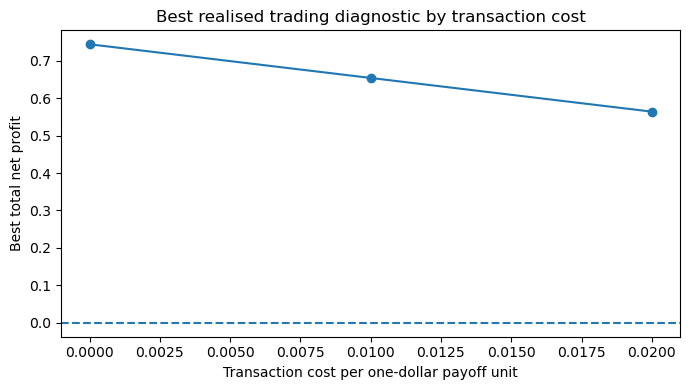

In [38]:
if not cost_stress_df.empty:
    ax = cost_stress_df.plot(
        x="transaction_cost_per_contract",
        y="best_total_net_profit",
        marker="o",
        figsize=(7, 4),
        legend=False,
        title="Best realised trading diagnostic by transaction cost",
    )
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Transaction cost per one-dollar payoff unit")
    ax.set_ylabel("Best total net profit")
    plt.tight_layout()
    plt.show()

## 13. Edge-buffer stress test

This table checks whether results are concentrated at very low edge buffers.

In [41]:
edge_stress_df = (
    strategy_summary_df
    .groupby(["model_source", "edge_buffer"], dropna=False)
    .agg(
        best_total_net_profit=("total_net_profit", "max"),
        best_return_on_capital=("return_on_capital", "max"),
        max_number_of_trades=("number_of_trades", "max"),
        average_trade_rate=("trade_rate", "mean"),
    )
    .reset_index()
    .sort_values(["model_source", "edge_buffer"])
)

edge_stress_df

,model_source,edge_buffer,best_total_net_profit,best_return_on_capital,max_number_of_trades,average_trade_rate
0,average_baseline_raw_weather,0.000,0.1600,0.041667,4,0.100
1,average_baseline_raw_weather,0.025,0.0735,0.038152,2,0.050
2,average_baseline_raw_weather,0.050,0.0000,NaN,0,0.000
3,average_baseline_raw_weather,0.075,0.0000,NaN,0,0.000
4,average_baseline_raw_weather,0.100,0.0000,NaN,0,0.000
5,average_baseline_raw_weather,0.150,0.0000,NaN,0,0.000
6,average_baseline_raw_weather,0.200,0.0000,NaN,0,0.000
7,calendar_threshold_baseline,0.000,-0.0660,-0.021526,5,0.125
8,calendar_threshold_baseline,0.025,-0.0495,-0.047165,2,0.050
9,calendar_threshold_baseline,0.050,0.0000,NaN,0,0.000


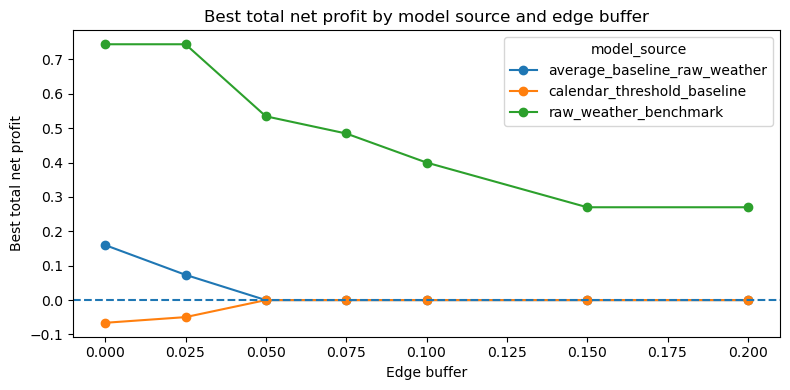

In [43]:
if not edge_stress_df.empty:
    edge_pivot = edge_stress_df.pivot(
        index="edge_buffer",
        columns="model_source",
        values="best_total_net_profit",
    )

    ax = edge_pivot.plot(
        marker="o",
        figsize=(8, 4),
        title="Best total net profit by model source and edge buffer",
    )
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Edge buffer")
    ax.set_ylabel("Best total net profit")
    plt.tight_layout()
    plt.show()

## 14. Robustness conclusions table

The conclusion table gives a compact status for each robustness dimension.

In [46]:
conclusion_rows = []

if not best_score_by_subset_df.empty:
    all_rows_best_source = best_score_by_subset_df.loc[
        best_score_by_subset_df["subset_name"] == "all_rows",
        "probability_source",
    ]

    all_rows_best_source_value = all_rows_best_source.iloc[0] if not all_rows_best_source.empty else None

    subset_best_sources = best_score_by_subset_df["probability_source"].dropna().unique().tolist()

    conclusion_rows.append({
        "robustness_dimension": "probability_source_ranking_across_subsets",
        "status": "stable" if len(subset_best_sources) == 1 else "sample_dependent",
        "main_finding": f"Best full-sample source: {all_rows_best_source_value}",
        "detail": f"Best sources observed across subsets: {subset_best_sources}",
    })

if not best_leave_one_threshold_df.empty:
    threshold_best_sources = best_leave_one_threshold_df["probability_source"].dropna().unique().tolist()

    conclusion_rows.append({
        "robustness_dimension": "leave_one_threshold_score_ranking",
        "status": "stable" if len(threshold_best_sources) == 1 else "sample_dependent",
        "main_finding": "Probability ranking after dropping one threshold at a time",
        "detail": f"Best sources observed: {threshold_best_sources}",
    })

if not best_leave_one_timing_df.empty:
    timing_best_sources = best_leave_one_timing_df["probability_source"].dropna().unique().tolist()

    conclusion_rows.append({
        "robustness_dimension": "leave_one_timing_score_ranking",
        "status": "stable" if len(timing_best_sources) == 1 else "sample_dependent",
        "main_finding": "Probability ranking after dropping one forecast timing at a time",
        "detail": f"Best sources observed: {timing_best_sources}",
    })

if not cost_stress_df.empty:
    positive_costs = cost_stress_df.loc[
        cost_stress_df["profit_positive"],
        "transaction_cost_per_contract",
    ].tolist()

    conclusion_rows.append({
        "robustness_dimension": "transaction_cost_sensitivity",
        "status": "stable" if len(positive_costs) == len(cost_stress_df) else "cost_sensitive",
        "main_finding": "Best realised trading diagnostic under transaction-cost assumptions",
        "detail": f"Positive-profit cost levels: {positive_costs}",
    })

if not best_leave_one_threshold_trade_df.empty:
    best_trade_sources_threshold = best_leave_one_threshold_trade_df["model_source"].dropna().unique().tolist()

    conclusion_rows.append({
        "robustness_dimension": "leave_one_threshold_trading_result",
        "status": "stable" if len(best_trade_sources_threshold) == 1 else "sample_dependent",
        "main_finding": "Best trading diagnostic after dropping one threshold at a time",
        "detail": f"Best model sources observed: {best_trade_sources_threshold}",
    })

if not best_leave_one_timing_trade_df.empty:
    best_trade_sources_timing = best_leave_one_timing_trade_df["model_source"].dropna().unique().tolist()

    conclusion_rows.append({
        "robustness_dimension": "leave_one_timing_trading_result",
        "status": "stable" if len(best_trade_sources_timing) == 1 else "sample_dependent",
        "main_finding": "Best trading diagnostic after dropping one timing at a time",
        "detail": f"Best model sources observed: {best_trade_sources_timing}",
    })

robustness_conclusions_df = pd.DataFrame(conclusion_rows)
robustness_conclusions_df

,robustness_dimension,status,main_finding,detail
0,probability_source_ranking_across_subsets,sample_dependent,Best full-sample source: market_implied_probab...,Best sources observed across subsets: ['market...
1,leave_one_threshold_score_ranking,stable,Probability ranking after dropping one thresho...,Best sources observed: ['market_implied_probab...
2,leave_one_timing_score_ranking,stable,Probability ranking after dropping one forecas...,Best sources observed: ['market_implied_probab...
3,transaction_cost_sensitivity,stable,Best realised trading diagnostic under transac...,"Positive-profit cost levels: [0.0, 0.01, 0.02]"
4,leave_one_threshold_trading_result,stable,Best trading diagnostic after dropping one thr...,Best model sources observed: ['raw_weather_ben...
5,leave_one_timing_trading_result,stable,Best trading diagnostic after dropping one tim...,Best model sources observed: ['raw_weather_ben...


## 15. Save outputs

In [49]:
output_paths = {
    "integrity_checks": PROCESSED_DIR / "hong_kong_integrity_checks.csv",
    "score_robustness": PROCESSED_DIR / "hong_kong_score_robustness_by_subset.csv",
    "best_score_by_subset": PROCESSED_DIR / "hong_kong_best_score_source_by_subset.csv",
    "leave_one_threshold_score": PROCESSED_DIR / "hong_kong_leave_one_threshold_score_robustness.csv",
    "best_leave_one_threshold_score": PROCESSED_DIR / "hong_kong_best_leave_one_threshold_score.csv",
    "leave_one_timing_score": PROCESSED_DIR / "hong_kong_leave_one_timing_score_robustness.csv",
    "best_leave_one_timing_score": PROCESSED_DIR / "hong_kong_best_leave_one_timing_score.csv",
    "trading_robustness": PROCESSED_DIR / "hong_kong_trading_robustness_by_subset.csv",
    "best_trading_by_subset": PROCESSED_DIR / "hong_kong_best_trading_rule_by_subset.csv",
    "leave_one_threshold_trade": PROCESSED_DIR / "hong_kong_leave_one_threshold_trade_robustness.csv",
    "best_leave_one_threshold_trade": PROCESSED_DIR / "hong_kong_best_leave_one_threshold_trade.csv",
    "leave_one_timing_trade": PROCESSED_DIR / "hong_kong_leave_one_timing_trade_robustness.csv",
    "best_leave_one_timing_trade": PROCESSED_DIR / "hong_kong_best_leave_one_timing_trade.csv",
    "cost_stress": PROCESSED_DIR / "hong_kong_transaction_cost_stress_test.csv",
    "edge_stress": PROCESSED_DIR / "hong_kong_edge_buffer_stress_test.csv",
    "robustness_conclusions": PROCESSED_DIR / "hong_kong_robustness_conclusions.csv",
}

integrity_checks_df.to_csv(output_paths["integrity_checks"], index=False)
score_robustness_df.to_csv(output_paths["score_robustness"], index=False)
best_score_by_subset_df.to_csv(output_paths["best_score_by_subset"], index=False)
leave_one_threshold_score_df.to_csv(output_paths["leave_one_threshold_score"], index=False)
best_leave_one_threshold_df.to_csv(output_paths["best_leave_one_threshold_score"], index=False)
leave_one_timing_score_df.to_csv(output_paths["leave_one_timing_score"], index=False)
best_leave_one_timing_df.to_csv(output_paths["best_leave_one_timing_score"], index=False)
trading_robustness_df.to_csv(output_paths["trading_robustness"], index=False)
best_trading_by_subset_df.to_csv(output_paths["best_trading_by_subset"], index=False)
leave_one_threshold_trade_df.to_csv(output_paths["leave_one_threshold_trade"], index=False)
best_leave_one_threshold_trade_df.to_csv(output_paths["best_leave_one_threshold_trade"], index=False)
leave_one_timing_trade_df.to_csv(output_paths["leave_one_timing_trade"], index=False)
best_leave_one_timing_trade_df.to_csv(output_paths["best_leave_one_timing_trade"], index=False)
cost_stress_df.to_csv(output_paths["cost_stress"], index=False)
edge_stress_df.to_csv(output_paths["edge_stress"], index=False)
robustness_conclusions_df.to_csv(output_paths["robustness_conclusions"], index=False)

for name, path in output_paths.items():
    print(f"Saved {name}: {path}")

Saved integrity_checks: ../data/processed/robustness_checks/hong_kong_integrity_checks.csv
Saved score_robustness: ../data/processed/robustness_checks/hong_kong_score_robustness_by_subset.csv
Saved best_score_by_subset: ../data/processed/robustness_checks/hong_kong_best_score_source_by_subset.csv
Saved leave_one_threshold_score: ../data/processed/robustness_checks/hong_kong_leave_one_threshold_score_robustness.csv
Saved best_leave_one_threshold_score: ../data/processed/robustness_checks/hong_kong_best_leave_one_threshold_score.csv
Saved leave_one_timing_score: ../data/processed/robustness_checks/hong_kong_leave_one_timing_score_robustness.csv
Saved best_leave_one_timing_score: ../data/processed/robustness_checks/hong_kong_best_leave_one_timing_score.csv
Saved trading_robustness: ../data/processed/robustness_checks/hong_kong_trading_robustness_by_subset.csv
Saved best_trading_by_subset: ../data/processed/robustness_checks/hong_kong_best_trading_rule_by_subset.csv
Saved leave_one_thresho

## 16. Interpretation

This notebook provides a robustness-check framework for the probability and trading diagnostics.

For the current Hong Kong example, results should remain interpreted as pipeline diagnostics. The sample is too small to support final claims about trading profitability, market efficiency or model superiority. Nevertheless, the robustness checks are useful because they reveal whether the current findings depend strongly on one threshold, one timing choice or one cost assumption.

The main outputs are the score-robustness tables, leave-one-out summaries, transaction-cost stress tests and the compact robustness-conclusions table. These outputs will become more important once the project is expanded across additional dates, cities and Polymarket weather contracts.